In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error 
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler ,LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split , GridSearchCV

import warnings 
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('archive (1)/social_media_productivity_6000.csv')
df = pd.DataFrame(df)

In [3]:
df

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09
...,...,...,...,...,...,...,...,...,...
5995,20.0,2.05,0.71,7.92,4.13,48.0,100.00,Low,84.55
5996,28.0,6.28,4.90,4.07,5.64,198.0,99.52,Medium,37.63
5997,19.0,3.97,3.40,0.93,6.10,183.0,98.65,Medium,6.67
5998,30.0,11.11,9.16,3.76,6.43,179.0,79.82,High,0.00


In [4]:
df.describe()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,productivity_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000
mean,27.111395,6.923175,4.145915,4.069328,6.514270,159.781463,96.363531,37.614051
std,7.268430,2.859055,2.155496,2.309472,1.434351,81.044666,7.416839,27.603251
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,0.000000
25%,21.000000,4.470000,2.400000,2.120000,5.270000,89.000000,96.360000,13.565000
50%,27.000000,6.860000,3.755000,4.115000,6.525000,160.000000,100.000000,36.200000
75%,33.000000,9.360000,5.540000,6.030000,7.730000,231.000000,100.000000,58.560000
max,39.000000,11.990000,10.660000,8.000000,9.000000,299.000000,100.000000,100.000000


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   object 
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), object(1)
memory usage: 422.0+ KB


In [6]:
df.isnull().sum()

age                      120
daily_screen_time        120
social_media_hours       120
study_hours              120
sleep_hours              120
notifications_per_day    120
focus_score              120
addiction_level          120
productivity_score       120
dtype: int64

# Filling the null value

In [7]:
null = ['age','daily_screen_time','social_media_hours','study_hours',
            'sleep_hours','notifications_per_day','focus_score','productivity_score']
for col in null:
    df[col].fillna(df[col].median(),inplace=True)

In [8]:
df['addiction_level'].fillna(df['addiction_level'].mode()[0], inplace=True)

In [9]:
df.isnull().sum()

age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
addiction_level          0
productivity_score       0
dtype: int64

In [10]:
df['addiction_level'].values

array(['Medium', 'Medium', 'Low', ..., 'Medium', 'High', 'Low'],
      shape=(6000,), dtype=object)

# Exploratory Data Analysis (EDA)

# Check Distribution of Target 


<Axes: >

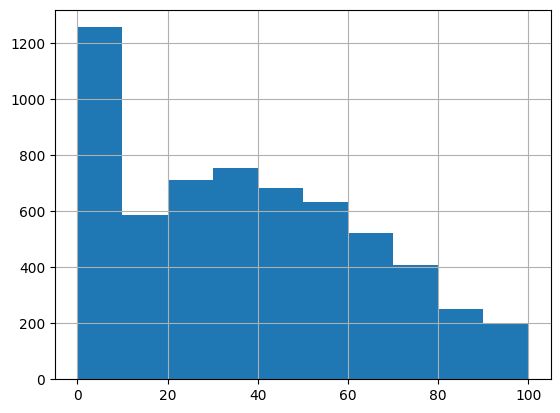

In [11]:
df['productivity_score'].hist()

In [12]:
df['productivity_score'].skew()

np.float64(0.2970542225526802)

In [13]:
df['productivity_score'].describe()

count    6000.000000
mean       37.585770
std        27.326495
min         0.000000
25%        14.310000
50%        36.200000
75%        58.135000
max       100.000000
Name: productivity_score, dtype: float64

In [14]:
df['productivity_score'].unique()

array([28.49, 18.54, 68.52, ..., 84.55,  6.67, 29.79], shape=(3831,))

# Check Feature Distribution 


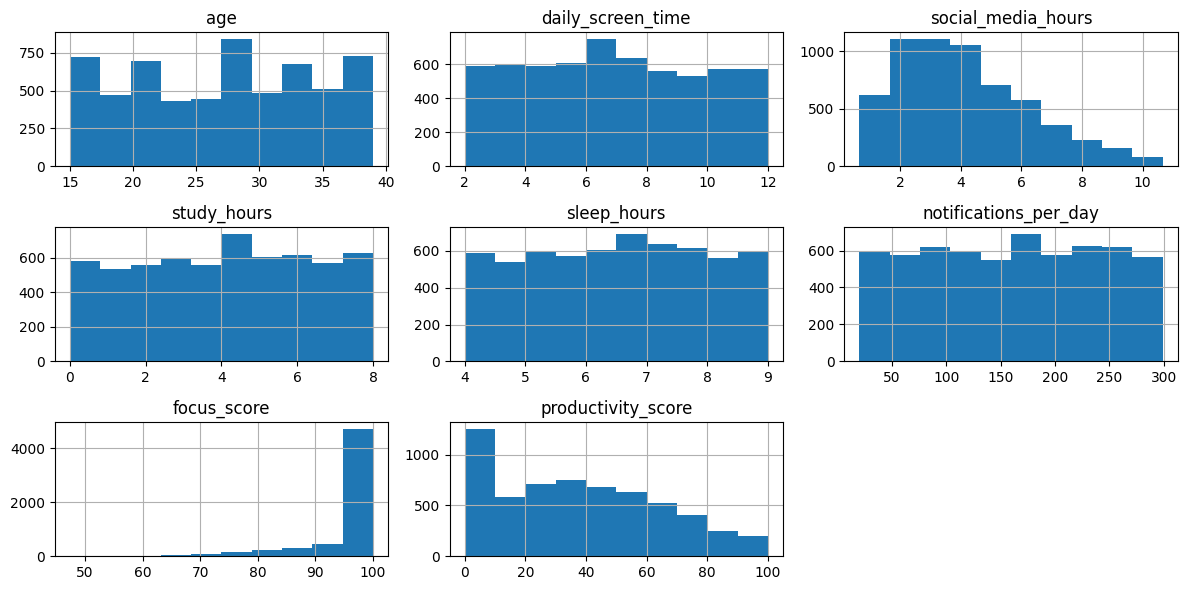

In [15]:
df.hist(figsize=(12,6))
plt.tight_layout()
plt.show()

# Check Relationships 

Text(0.5, 1.0, 'social_media_hours vs productivity_score')

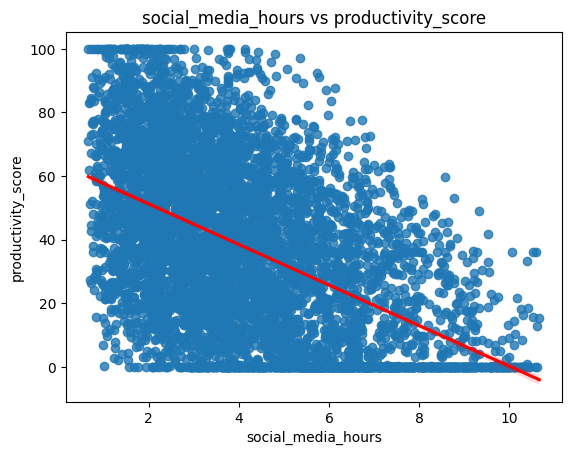

In [16]:
sns.regplot(x=df['social_media_hours'],y=df['productivity_score'],line_kws={'color':'red'})
plt.title('social_media_hours vs productivity_score')


#### So the line shows the negative relation when the social media hours increase the productivity will decrease

# Correlation 

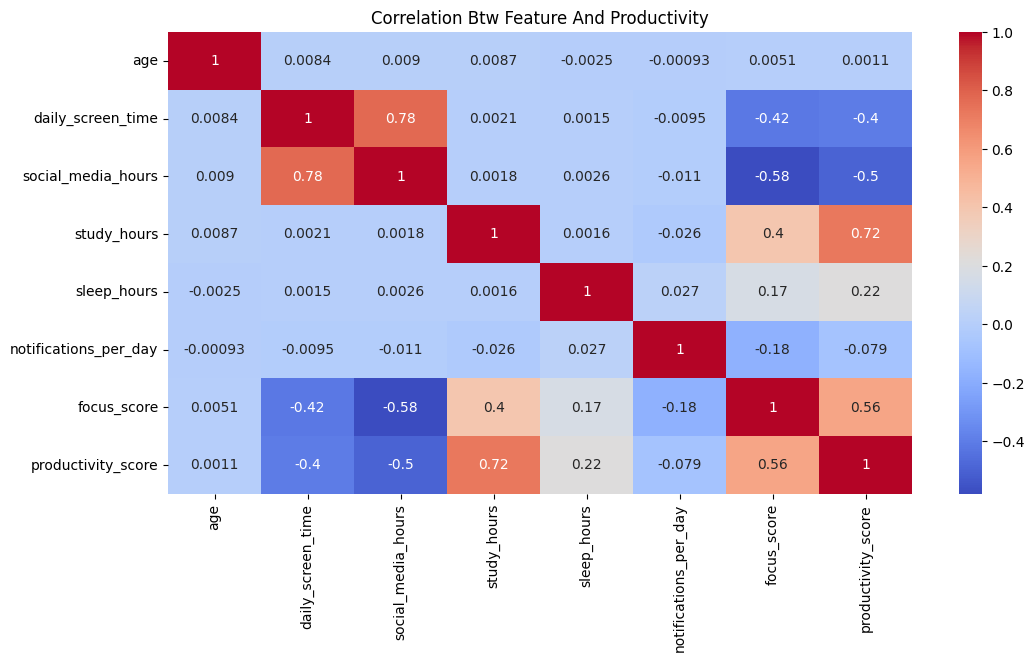

In [17]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Btw Feature And Productivity')
plt.show()

#### productivity and the focus_score has negative corr.. with social media and daily screen time


In [18]:
df['productivity_score'].value_counts(bins=5)

(-0.101, 20.0]    1843
(20.0, 40.0]      1466
(40.0, 60.0]      1315
(60.0, 80.0]       931
(80.0, 100.0]      445
Name: count, dtype: int64

# Encode Categorical Data

In [19]:
le = LabelEncoder()


In [20]:
df['addiction_level'] = le.fit_transform(df['addiction_level'])

# Define Features & Target


In [21]:
X = df.drop('productivity_score', axis=1)
y = df['productivity_score']

# Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


# Scaling Data Using Standard Scaler

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
x_df = pd.DataFrame(X_train)

In [25]:
x_df.head()

,0,1,2,3,4,5,6,7
0,0.120872,-0.693506,0.044688,-1.226063,1.289235,1.213841,-0.252389,0.882447
1,0.260741,0.453199,0.058611,-1.488243,0.123739,-1.222064,0.482046,0.882447
2,1.519564,-0.030181,-0.071330,0.207189,-1.578591,1.088923,-0.719019,0.882447
3,0.400610,1.557565,0.448433,1.400108,1.677733,0.289447,0.482046,-1.357804
4,-0.578474,0.474369,0.392744,0.495587,-0.398968,-0.709899,0.468520,0.882447


# Model Training And Selection 

In [28]:
random_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5]
}

xg_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

decision_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}


In [29]:
model = {
    'RandomForestRegressor':RandomForestRegressor(n_estimators=200, random_state=42 ),
    'XGBRegressor': XGBRegressor(),
    'LinearRegression': LinearRegression(),
    'DecisionTreeRegressor': DecisionTreeRegressor()
    
}

param_grids = {
    'RandomForestRegressor': random_grid,
    'XGBRegressor': xg_grid,
    'DecisionTreeRegressor': decision_grid
}

In [33]:
best_model = {}
for name , estimator in model.items():
    if name in param_grids:
        print(f'Running GridSearchCV for {name} ')


        grid_search = GridSearchCV(
            estimator=estimator,
            param_grid=param_grids[name],
            cv=5,
            scoring='r2',
            n_jobs=-1
        )

        grid_search.fit(X_train,y_train)

        best_model[name] = grid_search.best_estimator_

        print(f"Best Score for {name}: {grid_search.best_score_:.4f}")
        print(f"Best Params: {grid_search.best_params_}\n")
    else:
        print(f"Fitting {name} without GridSearch....")
        estimator.fit(X_train,y_train)
        best_model[name] = estimator 

        

Running GridSearchCV for RandomForestRegressor 
Best Score for RandomForestRegressor: 0.8389
Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}

Running GridSearchCV for XGBRegressor 
Best Score for XGBRegressor: 0.8467
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

Fitting LinearRegression without GridSearch....
Running GridSearchCV for DecisionTreeRegressor 
Best Score for DecisionTreeRegressor: 0.7693
Best Params: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}



In [38]:
result = []

for name ,md in best_model.items():
    preds = md.predict(X_test)

    R2 = r2_score(y_test,preds)
    MAE = mean_absolute_error(y_test,preds)
    RMSE = np.sqrt(mean_squared_error(y_test,preds))

    result.append({
        'Model': name,
        'R2 Score': R2, 
        'MAE': MAE,
        'RMSE': RMSE
        
    })

Result_df = pd.DataFrame(result).sort_values(by='R2 Score',ascending=False)
    

In [39]:
Result_df

,Model,R2 Score,MAE,RMSE
1,XGBRegressor,0.851086,7.990193,10.575814
0,RandomForestRegressor,0.845965,8.078788,10.756125
2,LinearRegression,0.835029,8.541518,11.131423
3,DecisionTreeRegressor,0.768080,10.090343,13.198215


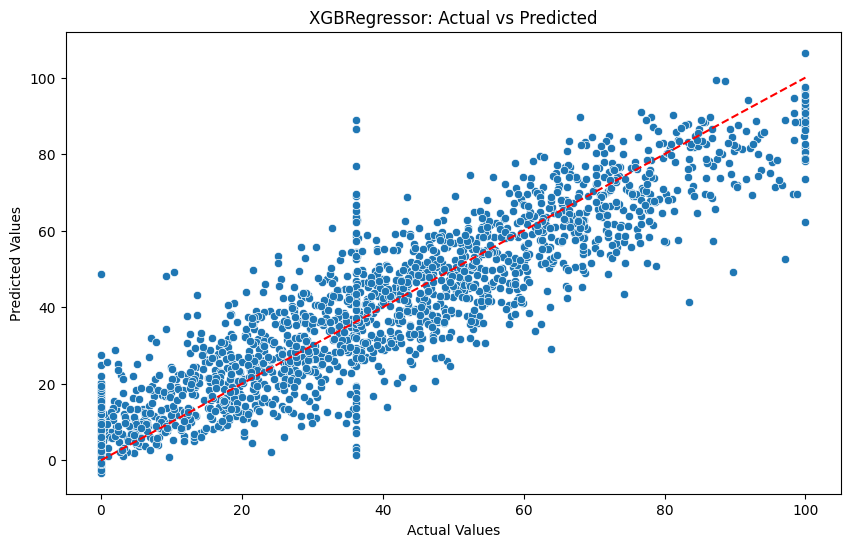

In [40]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test,y=best_model['XGBRegressor'].predict(X_test))
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('XGBRegressor: Actual vs Predicted')
plt.show()

In [41]:
y_test.mean()

np.float64(37.43762121212121)

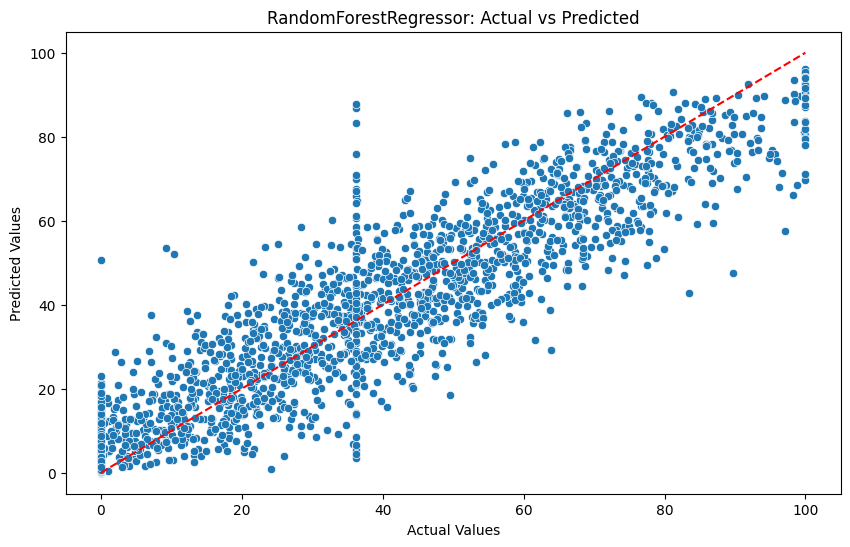

In [42]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test,y=best_model['RandomForestRegressor'].predict(X_test))
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('RandomForestRegressor: Actual vs Predicted')
plt.show()

In [60]:
# You need 8 values now to match x_df
# [age, screen_time, social_hrs, study_hrs, sleep_hrs, notes, focus, addiction_level]
new_data = [[25, 7.0, 3.5, 4.0, 7.0, 150, 95, 1]] # Added an 8th value here

# This will now work without the "7 vs 8" error
new_data_scaled = scaler.transform(new_data)
prediction = best_model['XGBRegressor'].predict(new_data_scaled)

print(f"Predicted Productivity Score: {prediction[0]:.2f}")

Predicted Productivity Score: 36.37


In [61]:
# Define 5 different scenarios [age, screen_time, social_hrs, study_hrs, sleep_hrs, notes, focus, addiction_level]
test_scenarios = {
    "The High Achiever": [[21, 2.0, 0.5, 8.0, 8.0, 30, 100, 0]],
    "The Social Media Addict": [[22, 11.0, 9.0, 1.0, 5.0, 250, 60, 2]],
    "The Balanced Student": [[25, 5.0, 3.0, 4.0, 7.0, 100, 85, 1]],
    "The Burned Out Professional": [[35, 8.0, 2.0, 2.0, 4.0, 200, 50, 1]],
    "The Focused Minimalist": [[30, 1.5, 0.0, 6.0, 9.0, 10, 100, 0]]
}

print("--- Multi-Scenario Test Results ---")
for name, data in test_scenarios.items():
    # Scale and Predict
    scaled_data = scaler.transform(data)
    pred = best_model['XGBRegressor'].predict(scaled_data)[0]
    
    print(f"{name:<25} | Predicted Score: {pred:.2f}")

--- Multi-Scenario Test Results ---
The High Achiever         | Predicted Score: 97.98
The Social Media Addict   | Predicted Score: -2.81
The Balanced Student      | Predicted Score: 32.72
The Burned Out Professional | Predicted Score: 15.38
The Focused Minimalist    | Predicted Score: 87.35


In [62]:
import joblib

joblib.dump(best_model['XGBRegressor'],'XGB_model.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(le,'Label_scaler(Addiction_level).pkl')

print("All components saved successfully")

All components saved successfully
